# Instructivo de Ejecución del Agente Orquestador

Este notebook guía paso a paso la ejecución del sistema de análisis de impacto de redes sociales en estudiantes.

## 1. Configuración del Entorno

Primero, asegúrese de tener instaladas las dependencias necesarias:

In [ ]:
# Ejecutar el agente orquestador
exec(open('analyzer.py', encoding='utf-8').read())

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Verificar Archivos del Proyecto

El proyecto debe contener los siguientes archivos:

In [2]:
import os

print("=== Estructura del Proyecto ===")
for file in os.listdir('.'):
    if file.endswith('.py') or file.endswith('.csv') or file.endswith('.md') or file.endswith('.txt'):
        print(f"  ✓ {file}")

=== Estructura del Proyecto ===
  ✓ agente.md
  ✓ analyzer.py
  ✓ Data set.csv
  ✓ requirements.txt
  ✓ skill_eda.py
  ✓ skill_modeling.py
  ✓ skill_preparation.py


## 3. Ejecutar el Agente Orquestador

El agente ejecuta automáticamente el pipeline completo:
1. **DataPreparationSkill**: Carga, limpieza, validación rigurosa, análisis de NaN y detección de outliers.
2. **EDASkill**: Genera visualizaciones (correlación, scatter plots, pairplot, análisis multivariado).
3. **PredictiveModelingSkill**: Compara modelos y selecciona el mejor con justificación técnica.

In [6]:
# Ejecutar el agente orquestador
exec(open('analyzer.py', encoding='utf-8').read())


=== INICIANDO PIPELINE DEL AGENTE ORQUESTADOR ===

[Skill: DataPreparation] Cargando y limpiando datos...

  [Análisis de NaN]
    Total de NaN: 0 (0.00% del dataset)
    ✓ No se detectaron valores NaN

  [Validación Rigurosa]
    ✓ Age: Todos los valores en rango válido
    ✓ Avg_Daily_Usage_Hours: Todos los valores en rango válido
    ✓ Sleep_Hours_Per_Night: Todos los valores en rango válido
    ✓ Mental_Health_Score: Todos los valores en rango válido
    ✓ Age: Tipo numérico correcto
    ✓ Avg_Daily_Usage_Hours: Tipo numérico correcto
    ✓ Sleep_Hours_Per_Night: Tipo numérico correcto
    ✓ Mental_Health_Score: Tipo numérico correcto

  [Detección de Outliers (IQR)]
    Age: Sin outliers significativos
    Avg_Daily_Usage_Hours: Sin outliers significativos
    Sleep_Hours_Per_Night: Sin outliers significativos
    Mental_Health_Score: Sin outliers significativos

  Finalizado: 1705 registros listos.
[Skill: EDA] Generando análisis visual...
  Generando Scatter Plots...
    ✓ Scat

## 4. Verificar Resultados Generados

Los gráficos se guardan en la carpeta `analysis_results/`:

In [7]:
import os

print("=== Archivos Generados en analysis_results/ ===")
if os.path.exists('analysis_results'):
    for file in sorted(os.listdir('analysis_results')):
        print(f"  📊 {file}")
else:
    print("  ⚠ La carpeta analysis_results no existe. Ejecute primero el agente.")

=== Archivos Generados en analysis_results/ ===
  📊 agente_correlation.png
  📊 agente_mental_health.png
  📊 agente_multivariate.png
  📊 agente_pairplot.png
  📊 agente_scatter_plots.png


## 5. Visualizar los Gráficos Generados

Cargue y visualice los gráficos generados:


📊 agente_correlation.png


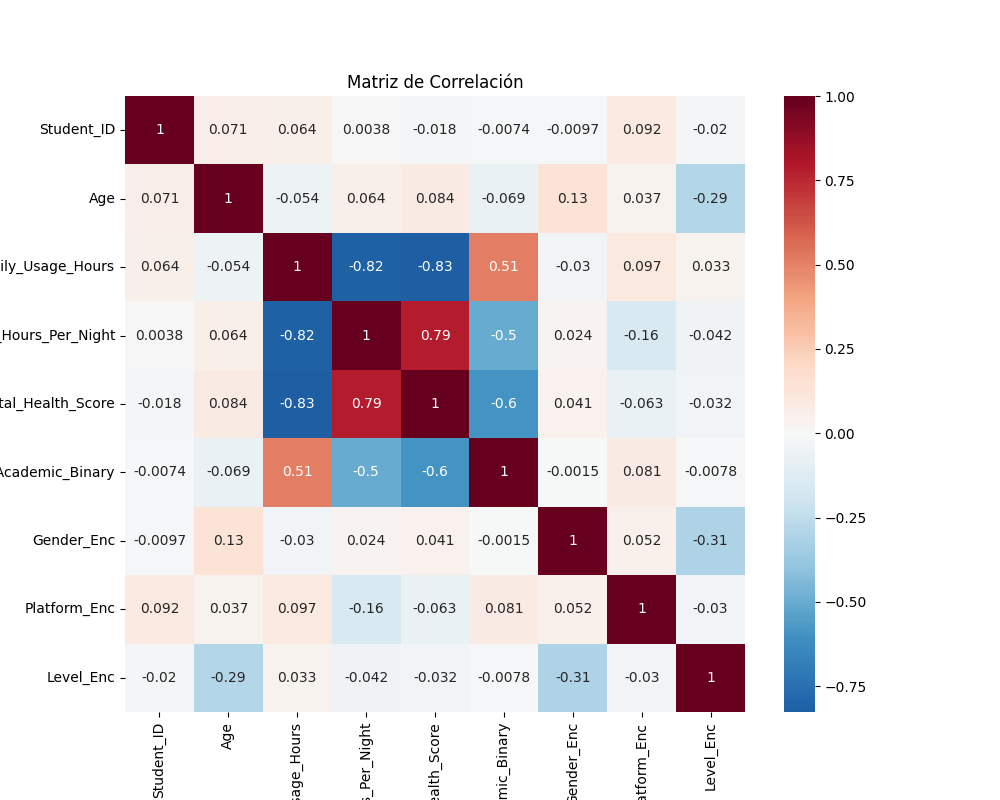


📊 agente_mental_health.png


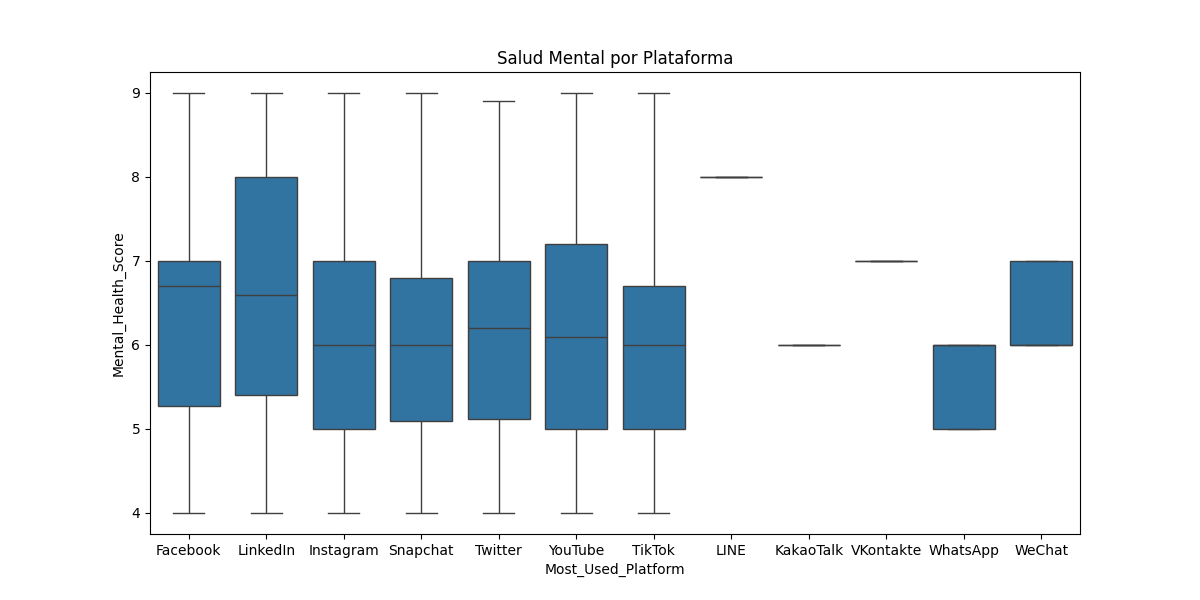


📊 agente_multivariate.png


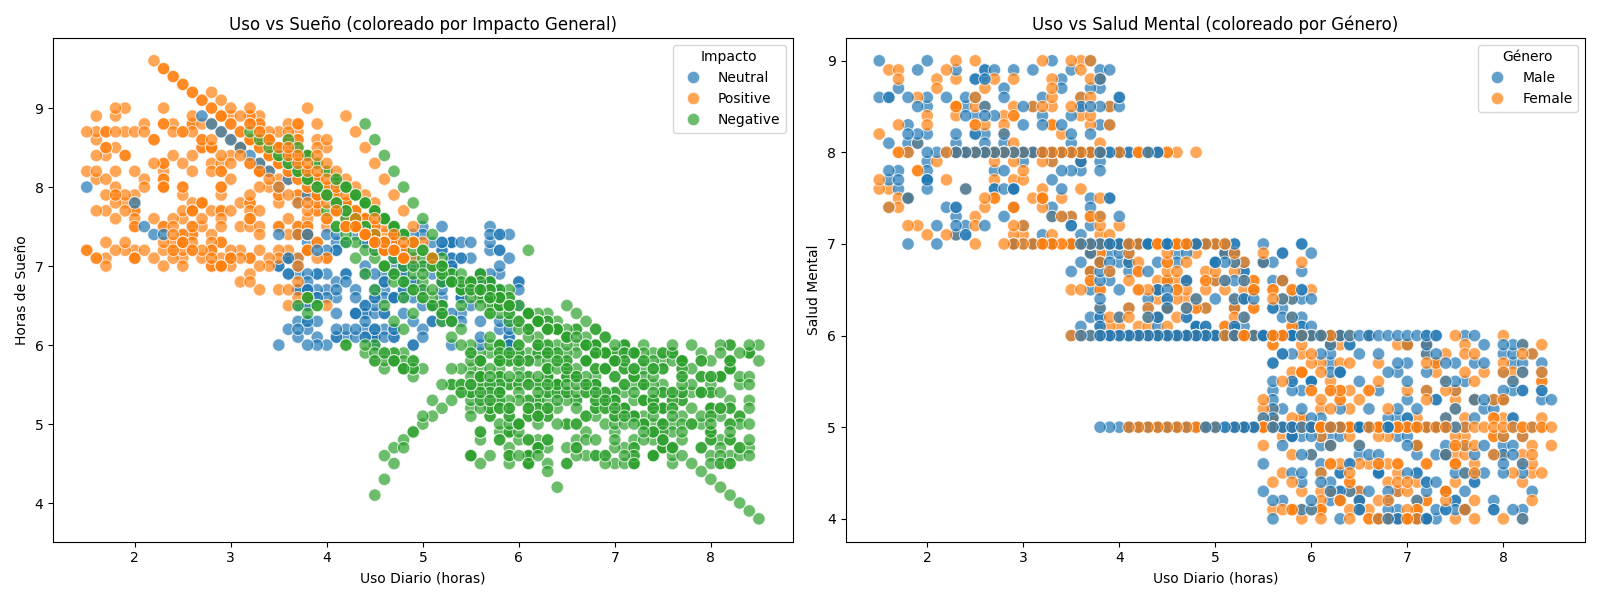


📊 agente_pairplot.png


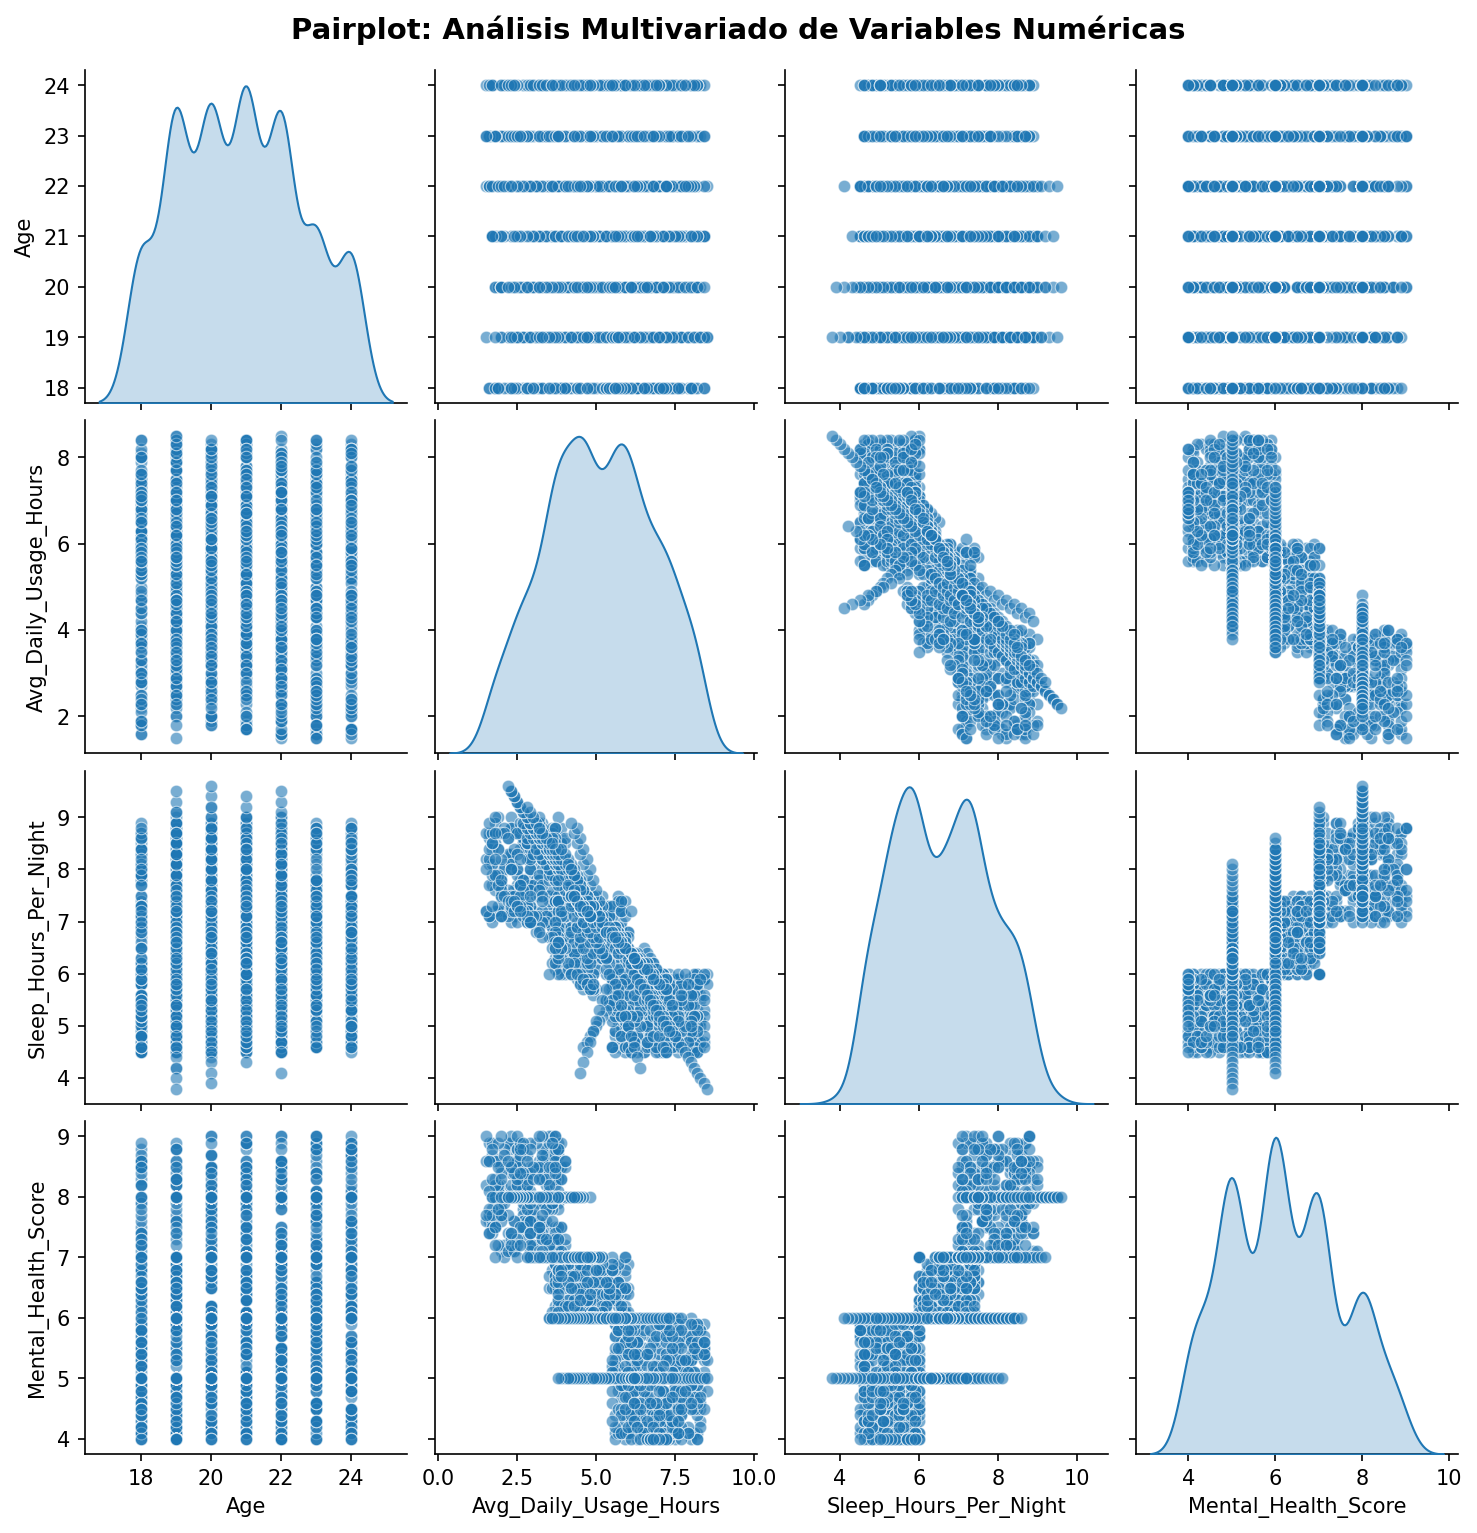


📊 agente_scatter_plots.png


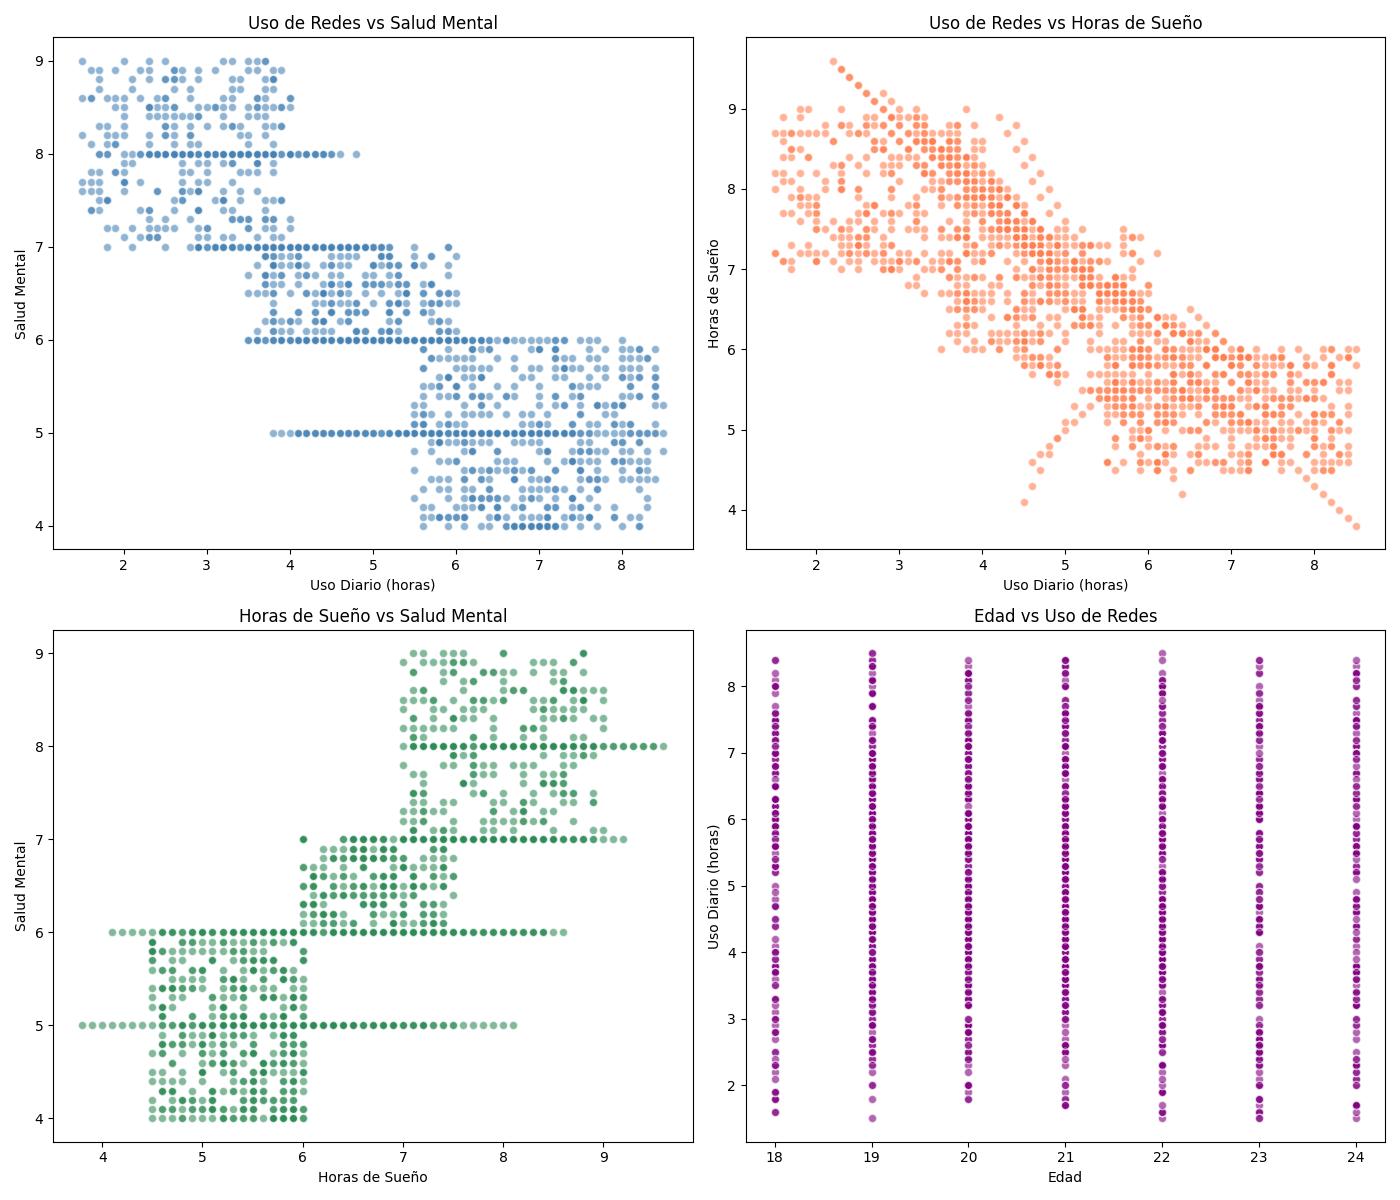

In [8]:
from IPython.display import Image, display
import os

output_dir = 'analysis_results'
if os.path.exists(output_dir):
    for file in sorted(os.listdir(output_dir)):
        if file.endswith('.png'):
            print(f"\n📊 {file}")
            display(Image(filename=os.path.join(output_dir, file)))

## 6. Ejecución de Skills Individuales (Opcional)

Para ejecutar skills de forma independiente:

In [9]:
# Ejecutar solo la skill de preparación
from skill_preparation import DataPreparationSkill

prep = DataPreparationSkill()
df = prep.execute('Data set.csv')
print(f"Registros preparados: {len(df) if df is not None else 0}")

[Skill: DataPreparation] Cargando y limpiando datos...

  [Análisis de NaN]
    Total de NaN: 0 (0.00% del dataset)
    ✓ No se detectaron valores NaN

  [Validación Rigurosa]
    ✓ Age: Todos los valores en rango válido
    ✓ Avg_Daily_Usage_Hours: Todos los valores en rango válido
    ✓ Sleep_Hours_Per_Night: Todos los valores en rango válido
    ✓ Mental_Health_Score: Todos los valores en rango válido
    ✓ Age: Tipo numérico correcto
    ✓ Avg_Daily_Usage_Hours: Tipo numérico correcto
    ✓ Sleep_Hours_Per_Night: Tipo numérico correcto
    ✓ Mental_Health_Score: Tipo numérico correcto

  [Detección de Outliers (IQR)]
    Age: Sin outliers significativos
    Avg_Daily_Usage_Hours: Sin outliers significativos
    Sleep_Hours_Per_Night: Sin outliers significativos
    Mental_Health_Score: Sin outliers significativos

  Finalizado: 1705 registros listos.
Registros preparados: 1705


In [10]:
# Ejecutar solo la skill de EDA
from skill_eda import EDASkill

eda = EDASkill()
eda.execute(df)

[Skill: EDA] Generando análisis visual...
  Generando Scatter Plots...
    ✓ Scatter plots guardados
  Generando Pairplot (Análisis Multivariado)...
    ✓ Pairplot guardado
  Generando Análisis Multivariado por Categorías...
    ✓ Análisis multivariado guardado
  Análisis guardado en analysis_results/


True

In [11]:
# Ejecutar solo la skill de modelado
from skill_modeling import PredictiveModelingSkill

modeling = PredictiveModelingSkill()
model, reason = modeling.execute(df)
print(f"Modelo final: {type(model).__name__}")
print(f"Justificación: {reason}")

[Skill: PredictiveModeling] Entrenando y comparando modelos...

  Comparación de Modelos:
    - Random Forest Accuracy: 0.9555
    - Logistic Regression Accuracy: 0.8759

  MODELO FINAL SELECCIONADO: RandomForestClassifier
  JUSTIFICACIÓN: Random Forest seleccionado automáticamente. Superó a la Regresión Logística por un margen de 0.0796 en accuracy. La justificación radica en su capacidad para modelar interacciones no lineales y su resistencia al sobreajuste mediante el uso de múltiples árboles de decisión.

  Reporte de Clasificación (Modelo Final):
              precision    recall  f1-score   support

    Negative       1.00      0.94      0.97       235
     Neutral       1.00      0.91      0.95        67
    Positive       0.87      1.00      0.93       125

    accuracy                           0.96       427
   macro avg       0.96      0.95      0.95       427
weighted avg       0.96      0.96      0.96       427

Modelo final: RandomForestClassifier
Justificación: Random Fo

## 7. Resumen del Pipeline

| Etapa | Skill | Salida |
|-------|-------|--------|
| 1 | DataPreparation | DataFrame limpio, reporte de NaN, validación de rangos, detección de outliers |
| 2 | EDA | 5 gráficos (correlación, boxplot, scatter plots, pairplot, multivariado) |
| 3 | PredictiveModeling | Modelo seleccionado con justificación técnica y métricas |